<a href="https://colab.research.google.com/github/deliperson/dsa107-labs/blob/main/Lab01_Environment_and_first_notebook_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSA 107 — Lab 1: Environment and first notebook

**Week 1 · w/c 28 September 2026** · paired with DSA 101 lecture week 1

**Name:** Utku Zeyd Çınar   **Student ID:** 26122121018

---

### What you will produce

A runnable Colab notebook, pushed to your own GitHub repository, that loads a dataset, answers four questions about it, and draws one labelled figure.

### Before you start

Run the setup cell below. If any import fails, run
`!pip install pandas matplotlib seaborn scikit-learn` in a new cell and try again.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.3 | numpy 2.1.3


## 1. Load the data

`pd.read_csv` accepts a URL as happily as a filename. Load the penguins dataset into a DataFrame called `penguins`.

In [14]:
penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")

# TODO: show the first five rows
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


## 2. How big is it, and what is in it?

Three commands answer almost every first question about a dataset:

- `.shape` — rows and columns
- `.info()` — column names, types, and how many non-missing values each has
- `.describe()` — summary statistics for the numeric columns

In [41]:
# TODO: print the shape, then call .info()
print(penguins.info)

<bound method DataFrame.info of     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    MALE  
1

In [38]:
# TODO: summary statistics for the numeric columns
print(penguins.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


### Missing values

`.isna()` gives a True/False table the same shape as the data. Summing it down the columns counts the missing values in each.

In [33]:
print(penguins.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [40]:
print(penguins.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


**Q1.** How many penguins are in the dataset, and how many columns describe each one?


**Q2.** Which column has the most missing values, and how many? Suggest one plausible reason a field measurement might be missing.

*Write your answers here.*

 **A1** there are 344 penguins in the dataset, and 7 columns that describes each one of them

 **A2** Sex columns has the most missing value and its number is 11? It can be because of they couldn't see their special places.

## 3. Selecting and filtering

A single column is `df["name"]`. Several columns is `df[["a", "b"]]` — note the double brackets. Rows are chosen with a condition: `df[df["col"] > 5]`.

In [43]:
# TODO: show only species, island and body_mass_g, first five rows

penguins[["species","island","body_mass_g"]]

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,4850.0
341,Gentoo,Biscoe,5750.0
342,Gentoo,Biscoe,5200.0


In [51]:
gentoo = penguins[penguins["species"] == "Gentoo"]
print(len(gentoo))

124


**Q3.** How many Gentoo penguins are there? What fraction of the dataset is that?
**A3** there are 124 Gentoo penguins, It is approximetly 1/3 of the dataset and it shows penguins whose species are gentoo

In [55]:
# TODO: compute and print the fraction
print(len(gentoo)/(len(penguins)))

0.36046511627906974


## 4. Your first figure

A scatter plot of two numeric columns, coloured by a third categorical one. Every figure in this course needs axis labels and a title — a plot without them is not a finished piece of work.

Text(0.5, 1.0, 'Scatter plot of flipper_legth_mm against body_mass_g, coloured by species')

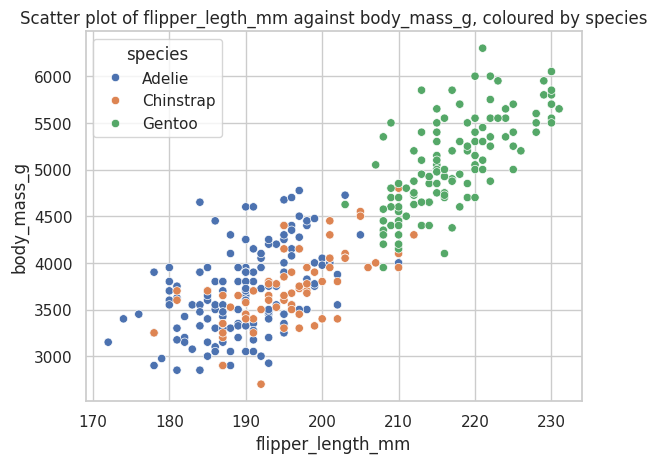

In [57]:
sns.scatterplot(data=penguins,x="flipper_length_mm",y="body_mass_g",hue="species")
plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.title("Scatter plot of flipper_legth_mm against body_mass_g, coloured by species")


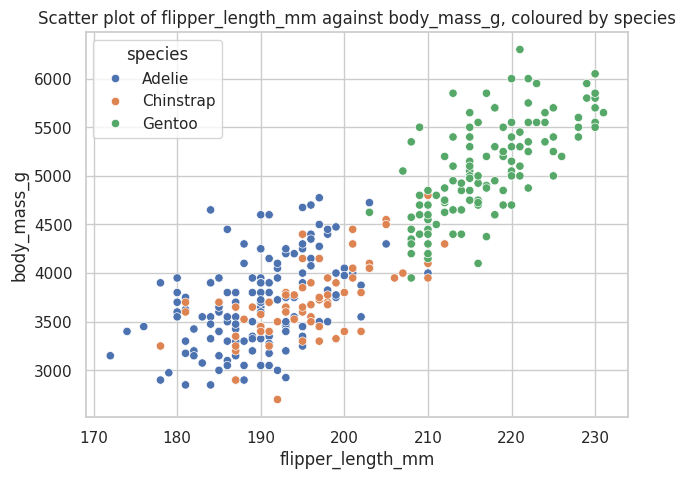

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))
# TODO: scatter plot of flipper_length_mm against body_mass_g,
#       coloured by species, with labels and a title
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.title("Scatter plot of flipper_length_mm against body_mass_g, coloured by species")
plt.show()

**Q4.** Describe the relationship in two sentences. Does it hold within every species, or only across all three together? What would you check next?

## 5. Push to GitHub

1. Create a repository named `dsa107-labs` on GitHub (public is fine).
2. In Colab: **File → Save a copy in GitHub**, choose that repository.
3. Paste the resulting link in the cell below.

**Repository link:** _______________

---

## Submission checklist

- [ ] Every cell runs top to bottom without error (Runtime → Restart and run all)
- [ ] Every written answer is filled in — a plot with no reading of it scores zero on interpretation
- [ ] Notebook saved as `Lab01_Firstname_Lastname.ipynb`
- [ ] Report exported as `Lab01_Firstname_Lastname.pdf`
- [ ] If you used an AI assistant, the log is attached as described in the course AI policy

Submit both files through MS Teams.